<a href="https://colab.research.google.com/github/NegativeGravity/Financial-Risk-Intelligence-Bankruptcy-Forecasting/blob/main/Quantative_Risk_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PROJECT: ALPHA-SME - THE ULTIMATE MLP QUANT
         "From First Principles to Financial AI Deployment Architect"

Phase 0

In [236]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

In [237]:
DATA_URL = "https://raw.githubusercontent.com/vcaramba/companies_bankruptcy_prediction/master/data/dataset.csv"

In [238]:
# 1. DATA ACQUISITION & GARBAGE COLLECTION

def run_phase_zero_cleaning(url: str) -> pd.DataFrame:
    print("-> Loading dataset...")
    df = pd.read_csv(url)
    print(f"-> Initial Shape: {df.shape[0]} rows, {df.shape[1]} columns")

    garbage_cols = ['Unnamed: 0', 'Unnamed: 0.1', 'id','bankruptcy_after_years']
    existing_garbage = [col for col in garbage_cols if col in df.columns]

    df_clean = df.drop(columns=existing_garbage)
    print(f"-> Action: Dropped garbage columns: {existing_garbage}")
    print(f"-> Cleaned Shape: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")

    return df_clean

In [239]:

print("\n[STEP 1] Executing Data Engineering Pipeline...")
DATA_URL = "https://raw.githubusercontent.com/vcaramba/companies_bankruptcy_prediction/master/data/dataset.csv"

df_clean = run_phase_zero_cleaning(DATA_URL)


[STEP 1] Executing Data Engineering Pipeline...
-> Loading dataset...
-> Initial Shape: 43405 rows, 70 columns
-> Action: Dropped garbage columns: ['Unnamed: 0', 'Unnamed: 0.1', 'id', 'bankruptcy_after_years']
-> Cleaned Shape: 43405 rows, 66 columns


In [240]:
df_clean.head()

,Attr1,Attr2,Attr3,Attr4,Attr5,Attr6,Attr7,Attr8,Attr9,Attr10,...,Attr57,Attr58,Attr59,Attr60,Attr61,Attr62,Attr63,Attr64,class,year
0,0.200550,0.37951,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.1389,0.50494,...,0.39718,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277,0,1
1,0.209120,0.49988,0.47225,1.9447,14.7860,0.00000,0.258340,0.99601,1.6996,0.49788,...,0.42002,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870,0,1
2,0.248660,0.69592,0.26713,1.5548,-1.1523,0.00000,0.309060,0.43695,1.3090,0.30408,...,0.81774,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.2078,0,1
3,0.081483,0.30734,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.0571,0.57353,...,0.14207,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.5497,0,1
4,0.187320,0.61323,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.1559,0.38677,...,0.48431,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.8980,0,1


In [241]:
# 2. TARGET ANALYSIS & LEAKAGE DETECTION

def profile_financial_risk(df: pd.DataFrame):
    print("\n================ FINANCIAL RISK PROFILE ================")

    target_col = 'class'
    target_counts = df[target_col].value_counts()

    class_0 = target_counts.get(0, 0)
    class_1 = target_counts.get(1, 0)
    default_rate = (class_1 / len(df)) * 100

    print("--- TARGET VARIABLE ('class') ---")
    print(f"Healthy SMEs (0): {class_0}")
    print(f"Bankrupt SMEs (1): {class_1}")
    print(f"Default Rate: {default_rate:.2f}%")

    if 'bankruptcy_after_years' in df.columns:
        df = df.drop(columns="bankruptcy_after_years")

    if 'year' in df.columns:
        years_present = sorted(df['year'].unique())

In [242]:
profile_financial_risk(df_clean)


================ FINANCIAL RISK PROFILE ================
--- TARGET VARIABLE ('class') ---
Healthy SMEs (0): 41314
Bankrupt SMEs (1): 2091
Default Rate: 4.82%


Phase 1

In [243]:
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler

In [244]:
# 1. Timw Walk Split

def time_walk_split(df: pd.DataFrame, target_col: str = 'class'):
    print("\n================ STRICT TIME-WALK TEMPORAL SPLITTING ================")

    if 'year' in df.columns:
        df = df.sort_values(by='year').reset_index(drop=True)
        years = sorted(df['year'].unique())
        print(f"-> Timeline Detected: {years}")

        test_year = years[-1]
        val_year = years[-2]
        train_years = years[:-2]

        df_train = df[df['year'].isin(train_years)]
        df_val = df[df['year'] == val_year]
        df_test = df[df['year'] == test_year]

        print(f"-> STRICT Boundary | Train: {train_years} | Val: [{val_year}] | Test: [{test_year}]")

    else:
        print("-> Warning: 'year' column not found! Falling back to 80-10-10 sequential ratio.")
        total_samples = len(df)
        df_train = df.iloc[:int(total_samples * 0.8)]
        df_val = df.iloc[int(total_samples * 0.8) : int(total_samples * 0.9)]
        df_test = df.iloc[int(total_samples * 0.9):]

    print(f"-> Final Distribution | Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

    X_train = df_train.drop(columns=[target_col]).values
    y_train = df_train[target_col].values.reshape(-1, 1)

    X_val = df_val.drop(columns=[target_col]).values
    y_val = df_val[target_col].values.reshape(-1, 1)

    X_test = df_test.drop(columns=[target_col]).values
    y_test = df_test[target_col].values.reshape(-1, 1)

    print("-> Strict Time-Walk Split Successful! Zero Leakage Verified.")

    return X_train, X_val, X_test, y_train, y_val, y_test

In [245]:
# 2. IMPUTATION PIPELINE

def handle_missing_values(X_train, X_val, X_test, strategy='knn'):
    print(f"\n================ MISSING VALUE IMPUTATION ================")
    print(f"-> Strategy Selected: '{strategy.upper()}'")

    if strategy == 'knn':
        imputer = KNNImputer(n_neighbors=5, weights='distance')
    else:
        imputer = SimpleImputer(strategy='median')

    print("-> Fitting imputer on Training data only (Preventing Leakage)...")
    X_train_imputed = imputer.fit_transform(X_train)

    print("-> Applying learned imputation rules to Validation and Test sets...")
    X_val_imputed = imputer.transform(X_val)
    X_test_imputed = imputer.transform(X_test)
    return X_train_imputed, X_val_imputed, X_test_imputed

In [246]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

def scale_features(X_train, X_val, X_test, method='standard'):
    print(f"\n================ FEATURE SCALING ================")
    print(f"-> Method Selected: '{method.upper()}'")

    if method == 'standard':
        scaler = StandardScaler()
    else:
        scaler = MinMaxScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_val_scaled, X_test_scaled

In [247]:
feature_names = df_clean.drop(columns=['class']).columns.tolist()
X_train_raw, X_val_raw, X_test_raw, y_train, y_val, y_test = time_walk_split(df_clean, target_col='class')

print("-> Applying KNN Imputation...")
X_train_imp, X_val_imp, X_test_imp = handle_missing_values(X_train_raw, X_val_raw, X_test_raw, strategy='knn')

print("-> Applying Standard Scaling...")
X_train, X_val, X_test = scale_features(X_train_imp, X_val_imp, X_test_imp, method='standard')

print(f"-> Final Data Shapes | Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")



================ STRICT TIME-WALK TEMPORAL SPLITTING ================
-> Timeline Detected: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
-> STRICT Boundary | Train: [np.int64(1), np.int64(2), np.int64(3)] | Val: [4] | Test: [5]
-> Final Distribution | Train: 27703 | Val: 9792 | Test: 5910
-> Strict Time-Walk Split Successful! Zero Leakage Verified.
-> Applying KNN Imputation...

================ MISSING VALUE IMPUTATION ================
-> Strategy Selected: 'KNN'
-> Fitting imputer on Training data only (Preventing Leakage)...
-> Applying learned imputation rules to Validation and Test sets...
-> Applying Standard Scaling...

================ FEATURE SCALING ================
-> Method Selected: 'STANDARD'
-> Final Data Shapes | Train: (27703, 65), Val: (9792, 65), Test: (5910, 65)


In [248]:
def visualize_quant_pipeline(y_train, X_train_raw, X_train_scaled, feature_names, feature_idx=0):
    fig = plt.figure(figsize=(18, 12))
    fig.suptitle("Alpha-SME: Phase 1 Data Profiling Report", fontsize=20, fontweight='bold')

    ax1 = plt.subplot(2, 2, 1)
    y_flat = y_train.flatten()
    classes, counts = np.unique(y_flat, return_counts=True)
    percentages = counts / len(y_flat) * 100

    sns.barplot(x=classes, y=counts, ax=ax1, palette="viridis")
    ax1.set_title("Target Imbalance (The Accuracy Trap)")
    ax1.set_xlabel("Class (0: Healthy, 1: Bankrupt)")
    ax1.set_ylabel("Number of Companies")

    for i, p in enumerate(ax1.patches):
        ax1.annotate(f"{percentages[i]:.2f}%\n({counts[i]})",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12)

    ax2 = plt.subplot(2, 2, 2)
    feature_name = feature_names[feature_idx]

    sns.kdeplot(X_train_raw[:, feature_idx], ax=ax2, label="Raw Data (Pre-Scale)", fill=True, alpha=0.5)
    sns.kdeplot(X_train_scaled[:, feature_idx], ax=ax2, label="Standard Scaled", fill=True, alpha=0.5)

    ax2.set_title(f"Scaling Impact on {feature_name}")
    ax2.set_xlabel("Feature Value")
    ax2.set_ylabel("Density")
    ax2.legend()
    ax2.set_xlim(-10, 10)

    ax3 = plt.subplot(2, 1, 2)
    subset_cols_names = feature_names[:15]
    subset_df = pd.DataFrame(X_train_scaled[:, :15], columns=subset_cols_names)
    corr_matrix = subset_df.corr()

    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm',
                vmax=1, vmin=-1, center=0, square=True, linewidths=.5, ax=ax3)

    ax3.set_title("Correlation Heatmap (Subset: Attr1 to Attr15)")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

/tmp/ipykernel_4859/2421480906.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classes, y=counts, ax=ax1, palette="viridis")


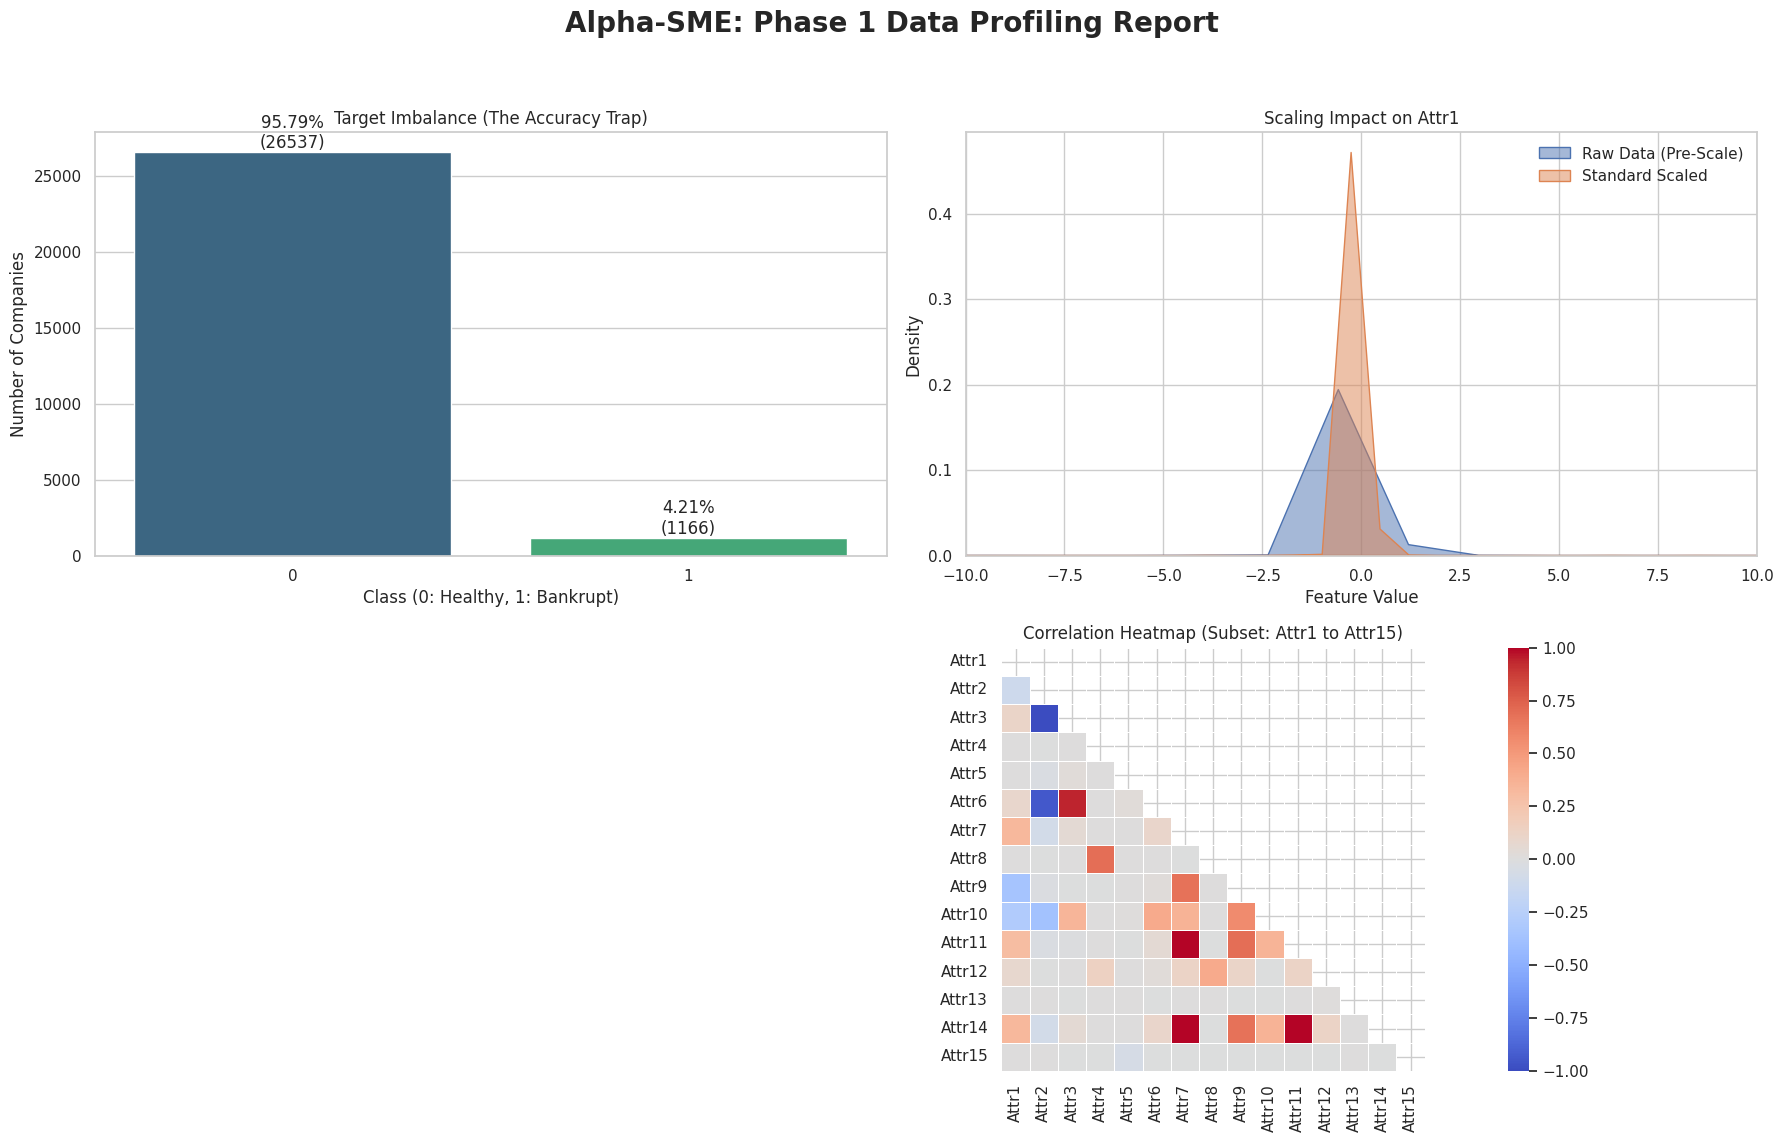

In [249]:
visualize_quant_pipeline(
    y_train=y_train,
    X_train_raw=X_train_imp,
    X_train_scaled=X_train,
    feature_names=feature_names,
    feature_idx=0
)

Phase 2

In [250]:
# 1.ACTIVATION FUNCTIONS

class Activation:

  def forward(self, x):
    raise NotImplementedError

  def backward(self, x):
    # to be implemented on Phase 3
    pass

class Sigmoid(Activation):
  def forward(self, x):
    x = np.clip(x, -500, 500)
    return 1.0 / (1.0 + np.exp(-x))

  def backward(self, x):
    return self.forward(x) * (1.0 - self.forward(x))

class Tanh(Activation):
  def forward(self, x):
    return np.tanh(x)

class ReLU(Activation):
    def forward(self, x):
        return np.maximum(0, x)

    def backward(self, d_out):
        d_x = np.array(d_out, copy=True)
        d_x[self.x <= 0] = 0
        return d_x

class LeakyReLU(Activation):
    def __init__(self, alpha=0.01):
        self.alpha = alpha
        self.x = None

    def forward(self, x):
        self.x = x
        return np.where(x > 0, x, x * self.alpha)

    def backward(self, d_out):
        d_x = np.ones_like(self.x)
        d_x[self.x <= 0] = self.alpha

        return d_out * d_x

In [251]:
# 2. PERCEPTRON ANATOMY & INITIALIZATION

class DenseLayer:
  def __init__(self, input_dim, output_dim, init_method="he"):
    self.input_dim = input_dim
    self.output_dim = output_dim
    self.init_method = init_method

    self.inputs = None

    self.bias = np.zeros((1, output_dim))

    if init_method == "zero":
      self.weights = np.zeros((input_dim, output_dim))
    elif init_method == "he":
      self.weights = np.random.randn(input_dim, output_dim) * np.sqrt(2 / input_dim)
    elif init_method == "xavier":
      limit = np.sqrt(6.0 / input_dim + output_dim)
      self.weights = np.random.inform(-limit, limit, (input_dim, output_dim))
    else:
      raise ValueError("Invalid initialization method.")

def forward(self, inputs):
  self.inputs = inputs
  return np.dot(inputs, self.weights) + self.bias

def backward(self, d_out):
        self.d_weights = np.dot(self.inputs.T, d_out)
        self.d_bias = np.sum(d_out, axis=0, keepdims=True)
        d_inputs = np.dot(d_out, self.weights.T)
        return d_inputs

In [255]:
# 3. VISUALIZATION (DYING RELU VS LEAKY RELU)

def plot_activation_battle():

  x = np.linspace(-10,10,200)

  relu = ReLU()
  leaky_relu = LeakyReLU(alpha=0.1)

  relu_y = relu.forward(x)
  leaky_relu_y = leaky_relu.forward(x)

  plt.figure(figsize=(10, 6))
  plt.style.use('seaborn-v0_8-darkgrid')

  plt.plot(x, relu_y, label='Standard ReLU', linewidth=3, color='blue', alpha=0.7)
  plt.plot(x, leaky_relu_y, label='Leaky ReLU (α=0.1)', linewidth=2, color='orange', linestyle='--')

  plt.axvspan(-10, 0, color='red', alpha=0.1, label='Dying ReLU Danger Zone')

  plt.axhline(0, color='black', linewidth=1)
  plt.axvline(0, color='black', linewidth=1)
  plt.title("The Activations Battle: ReLU vs Leaky ReLU", fontsize=14, fontweight='bold')
  plt.xlabel("Input (Z)", fontsize=12)
  plt.ylabel("Output (Activation)", fontsize=12)
  plt.legend(loc='upper left', fontsize=11)

  plt.tight_layout()
  plt.show()

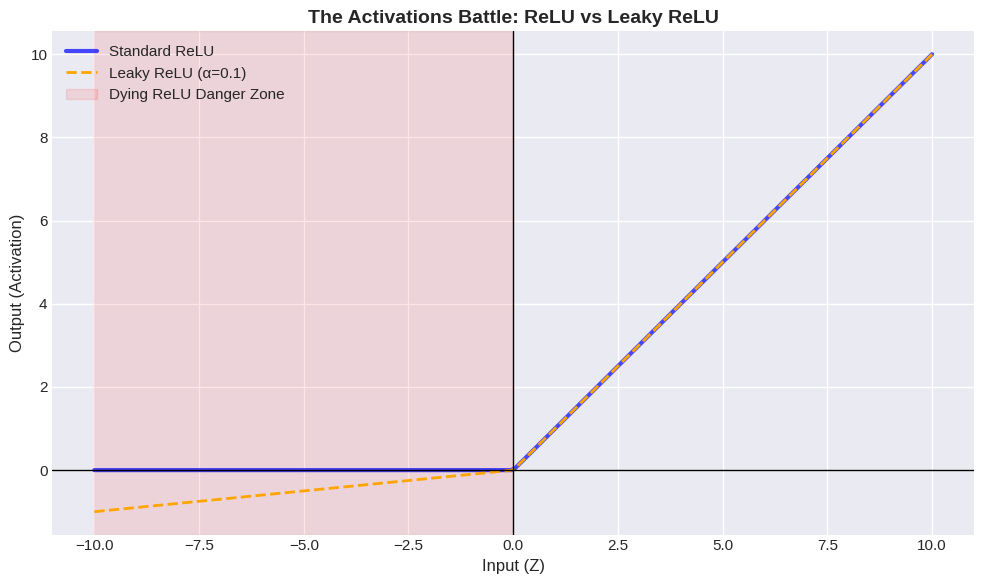

In [256]:
plot_activation_battle()

Phase 3

In [257]:
# 1. BINARY CROSS ENTROPY LOSS

class BCELoss:
  def __init__(self):
    self.eps = 1e-15

  def forward(self, y_true, y_pred):
    self.y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7)
    self.y_true = y_true

    return -np.mean(y_true * np.log(self.y_pred) + (1-y_true) * np.log(1-self.y_pred))

  def backward(self):
    batch_size = self.y_true.shape[0]
    d_pred = -(self.y_true / self.y_pred) + ((1 - self.y_true) / (1 - self.y_pred))
    return d_pred / batch_size

In [258]:
# 2. ADAM OPTIMIZER & GRADIENT CLIPPING

class AdamOptimzer:
  def __init__(self, layers, lr=0.001, beta1=0.9, beta2=0.999, clip_value=1.0):
    self.layers = layers
    self.lr = lr
    self.beta1 = beta1
    self.beta2 = beta2
    self.clip_value = clip_value

    self.t = 0

    self.m = [{'w': np.zeros_like(l.weights), 'b': np.zeros_like(l.bias)} for l in layers]
    self.v = [{'w': np.zeros_like(l.weights), 'b': np.zeros_like(l.bias)} for l in layers]

  def step(self):
    self.t += 1

    for i, layer in enumerate(self.layers):
      # GRADIENT CLIPPING: Defends against Exploding Gradients
      dw = np.clip(layer.d_weights, -self.clip_value, self.clip_value)
      db = np.clip(layer.d_bias, -self.clip_value, self.clip_value)

      # Update biased first moment estimate (Momentum)
      self.m[i]['w'] = self.beta1 * self.m[i]['w'] + (1 - self.beta1) * dw
      self.m[i]['b'] = self.beta1 * self.m[i]['b'] + (1 - self.beta1) * db

      # Update biased second raw moment estimate (RMSprop)
      self.v[i]['w'] = self.beta2 * self.v[i]['w'] + (1 - self.beta2) * dw**2
      self.v[i]['b'] = self.beta2 * self.v[i]['b'] + (1 - self.beta2) * db**2

      # Compute bias-corrected first and second moment estimates
      m_hat_w = self.m[i]['w'] / (1 - self.beta1**self.t)
      m_hat_b = self.m[i]['b'] / (1 - self.beta1**self.t)

      v_hat_w = self.v[i]['w'] / (1 - self.beta2 ** self.t)
      v_hat_b = self.v[i]['b'] / (1 - self.beta2 ** self.t)

      # Update neural network weights
      layer.weights -= self.lr * m_hat_w / (np.sqrt(v_hat_w) + 1e-8)
      layer.bias -= self.lr * m_hat_b / (np.sqrt(v_hat_b) + 1e-8)

In [259]:
def plot_optimizer_trajectory():
    x = np.linspace(-10, 10, 100)
    y = np.linspace(-5, 5, 100)
    X, Y = np.meshgrid(x, y)
    Z = X**2 + 4 * Y**2

    sgd_path_x = [-8, -7.5, -6.5, -5.0, -4.5, -3.0, -2.5, -1.0, -0.5, 0]
    sgd_path_y = [4, -3, 2.5, -1.8, 1.2, -0.8, 0.5, -0.2, 0.1, 0]

    adam_path_x = [-8, -6, -4, -2, -0.5, 0]
    adam_path_y = [4, 1.5, 0.5, 0.1, 0.05, 0]

    plt.figure(figsize=(10, 7))
    plt.style.use('seaborn-v0_8-darkgrid')

    contour = plt.contour(X, Y, Z, levels=np.logspace(-0.5, 3.5, 20), cmap='viridis', alpha=0.6)
    plt.clabel(contour, inline=True, fontsize=8)

    plt.plot(sgd_path_x, sgd_path_y, 'o-', color='red', label='SGD (Zigzag / Slow)', linewidth=2, markersize=5)
    plt.plot(adam_path_x, adam_path_y, 's-', color='blue', label='Adam (Adaptive / Fast)', linewidth=3, markersize=6)

    plt.plot(-8, 4, 'k*', markersize=12, label='Initialization Point')
    plt.plot(0, 0, 'rX', markersize=12, label='Global Minimum (Optimal Weights)')

    plt.title("Optimization Trajectory: SGD vs Adam on Loss Landscape", fontsize=14, fontweight='bold')
    plt.xlabel("Weight 1 ($W_1$)", fontsize=12)
    plt.ylabel("Weight 2 ($W_2$)", fontsize=12)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

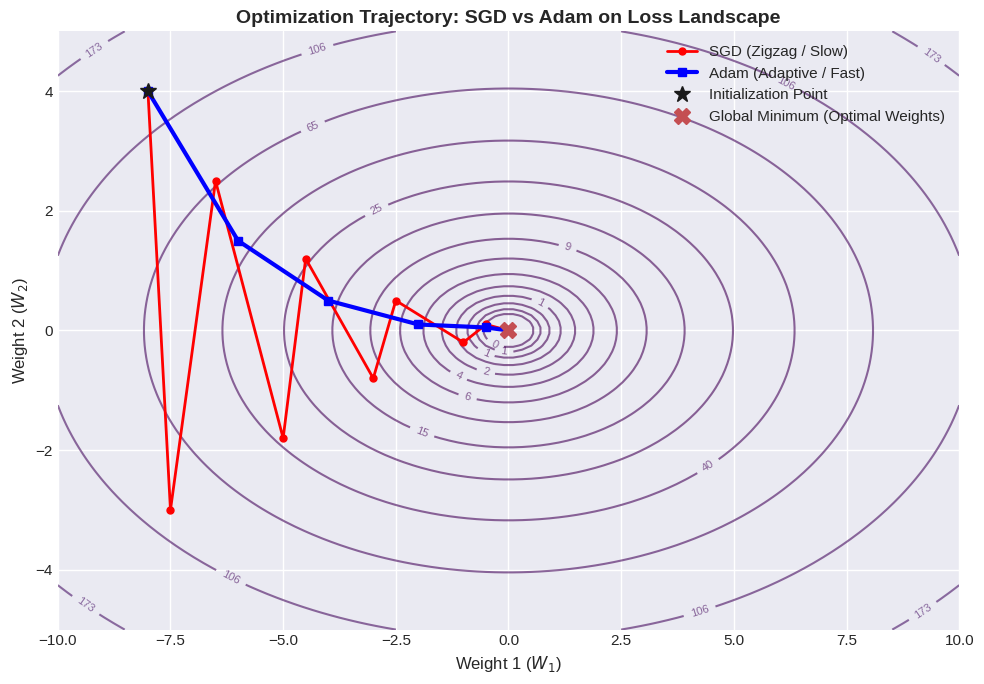

In [260]:
plot_optimizer_trajectory()

Phase 4

In [261]:
# 1. INVERTED DROPOUT

class Dropout:
  def __init__(self, dropout_rate):
    self.dropout_rate = dropout_rate
    self.keep_prob = 1.0 - dropout_rate
    self.mask = None

  def forward(self, x, is_training=True):
    if not is_training or self.keep_prob == 1.0:
            return x
    self.mask = (np.random.rand(*x.shape) < self.keep_prob) / self.keep_prob
    return x * self.mask

  def backward(self,d_out):
    return d_out * self.mask

In [262]:
# 2. BATCH NORMALIZATION (1D)

class BatchNormalization:
  def __init__(self, num_features, momentum=0.9, epsilon=1e-5):
    self.gamma = np.ones((1, num_features))
    self.beta = np.zeros((1, num_features))
    self.momentum = momentum
    self.eps = epsilon

    self.running_mean = np.zeros((1, num_features))
    self.running_var = np.zeros((1, num_features))

  def forward(self, x, is_training=True):
    if is_training:
      self.batch_mean = np.mean(x, axis=0, keepdims=True)
      self.batch_var = np.var(x, axis=0, keepdims=True)

      self.x_norm = (x - self.batch_mean) / np.sqrt(self.batch_var + self.eps)

      self.running_mean = self.momentum * self.running_mean + (1 - self.momentum) * self.batch_mean
      self.running_var = self.momentum * self.running_var + (1 - self.momentum) * self.batch_var

      out = self.gamma * self.x_norm + self.beta
      return out
    else:
      x_norm = (x - self.running_mean) / np.sqrt(self.running_var + self.eps)
      out = self.gamma * x_norm + self.beta
      return out

  def backward(self, d_out, x):
    N = x.shape[0]

    d_gamma = np.sum(d_out * self.x_norm, axis=0, keepdims=True)
    d_beta = np.sum(d_out, axis=0, keepdims=True)

    dx_norm = d_out * self.gamma
    d_var = np.sum(dx_norm * (x - self.batch_mean) * -0.5 * (self.batch_var + self.eps)**(-1.5), axis=0, keepdims=True)
    d_mean = np.sum(dx_norm * -1.0 / np.sqrt(self.batch_var + self.eps), axis=0, keepdims=True) + d_var * np.mean(-2.0 * (x - self.batch_mean), axis=0, keepdims=True)
    dx = (dx_norm / np.sqrt(self.batch_var + self.eps)) + (d_var * 2.0 * (x - self.batch_mean) / N) + (d_mean / N)

    return dx, d_gamma, d_beta

In [263]:
# 3. L2 REGULARIZATION (Modifying DenseLayer)

class RegularizedDenseLayer:
    def __init__(self, input_dim, output_dim, l2_lambda=0.01):
        self.weights = np.random.randn(input_dim, output_dim) * np.sqrt(2.0 / input_dim)
        self.bias = np.zeros((1, output_dim))
        self.l2_lambda = l2_lambda

    def forward(self, inputs):
        self.inputs = inputs
        return np.dot(inputs, self.weights) + self.bias

    def backward(self, d_out):
        self.d_weights = np.dot(self.inputs.T, d_out)
        self.d_bias = np.sum(d_out, axis=0, keepdims=True)
        d_inputs = np.dot(d_out, self.weights.T)

        self.d_weights += self.l2_lambda * self.weights

        return d_inputs

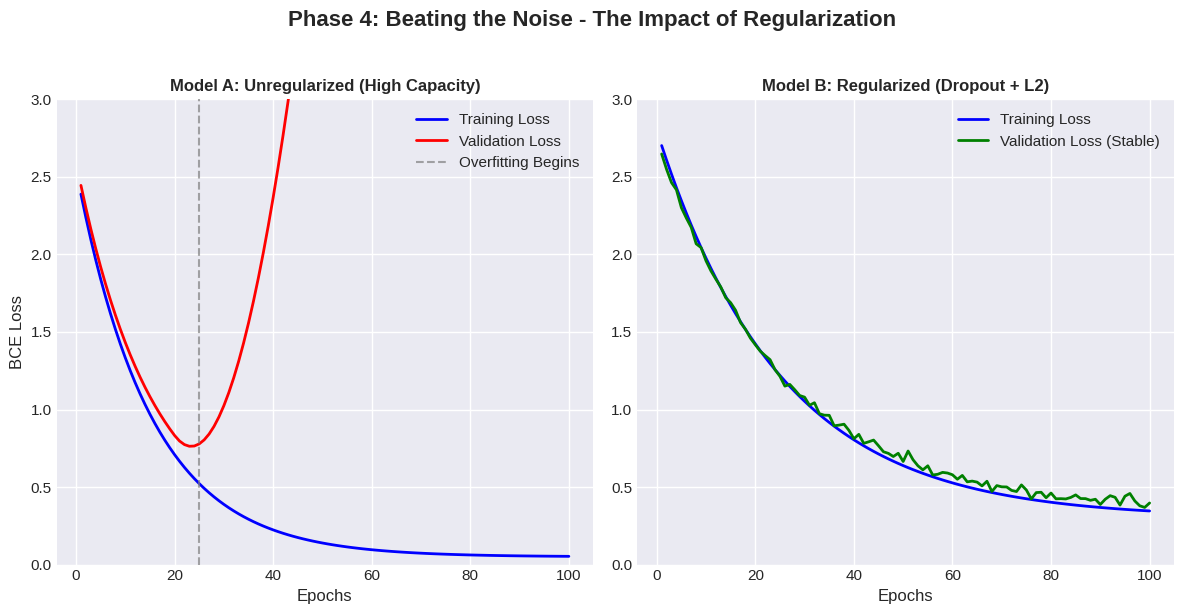

In [264]:
# 4. VISUALIZATION (IDENTIFYING OVERFITTING)

def plot_overfitting_vs_regularization():
    epochs = np.arange(1, 101)

    train_loss_unreg = 2.5 * np.exp(-epochs/15) + 0.05
    val_loss_unreg = 2.4 * np.exp(-epochs/15) + 0.2 + 0.005 * (epochs - 20)**2 * (epochs > 20)

    train_loss_reg = 2.5 * np.exp(-epochs/25) + 0.3
    val_loss_reg = 2.4 * np.exp(-epochs/25) + 0.35 + np.random.normal(0, 0.02, 100)

    plt.figure(figsize=(12, 6))
    plt.style.use('seaborn-v0_8-darkgrid')

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss_unreg, label='Training Loss', color='blue', linewidth=2)
    plt.plot(epochs, val_loss_unreg, label='Validation Loss', color='red', linewidth=2)
    plt.axvline(x=25, color='gray', linestyle='--', alpha=0.7, label='Overfitting Begins')
    plt.title("Model A: Unregularized (High Capacity)", fontweight='bold')
    plt.xlabel("Epochs")
    plt.ylabel("BCE Loss")
    plt.ylim(0, 3)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_loss_reg, label='Training Loss', color='blue', linewidth=2)
    plt.plot(epochs, val_loss_reg, label='Validation Loss (Stable)', color='green', linewidth=2)
    plt.title("Model B: Regularized (Dropout + L2)", fontweight='bold')
    plt.xlabel("Epochs")
    plt.ylim(0, 3)
    plt.legend()

    plt.suptitle("Phase 4: Beating the Noise - The Impact of Regularization", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_overfitting_vs_regularization()

Phase 5

In [265]:
# 1. EXPERT METRICS & CALIBRATION

class QuantMetrics:
  @staticmethod
  def confusion_matrix(y_true, y_pred_probs, threshold=0.5):
    y_pred = (y_pred_probs >= threshold).astype(int)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp, tn, fp, fn

  @staticmethod
  def classification_report(y_true, y_pred_probs, threshold=0.5):
    tp, tn, fp, fn = QuantMetrics.confusion_matrix(y_true, y_pred_probs,threshold)
    percision = tp / (tp + fp)
    recall = tp / (tp + fn)

    epsilon = 1e-7
    f1_score = 2 * (precision * recall) / (precision + recall + epsilon)
    return percision, recall, f1_score

  @staticmethod
  def brier_score(y_true, y_pred_probs):
    return np.mean(np.square(y_true - y_pred_probs))

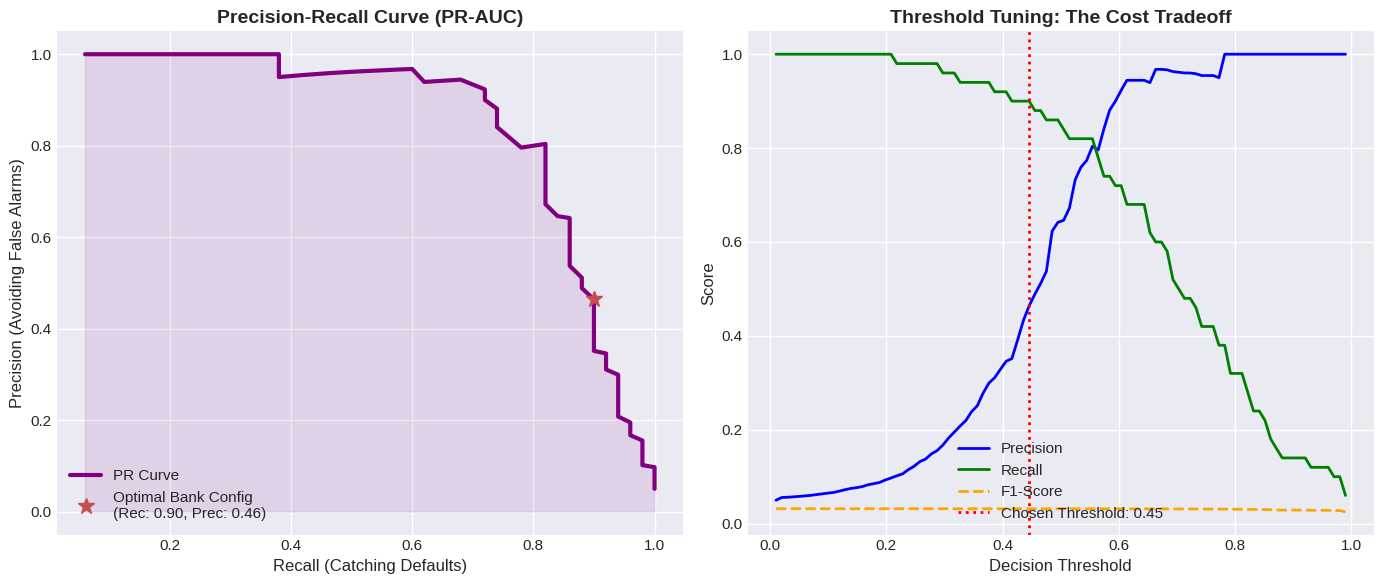

In [266]:
# 2. VISUALIZATION (PRECISION-RECALL & THRESHOLD TUNING)

def plot_pr_curve_and_tradeoff():
    np.random.seed(42)
    y_true = np.concatenate([np.zeros(950), np.ones(50)])

    probs_healthy = np.clip(np.random.normal(0.2, 0.15, 950), 0.01, 0.99)
    probs_bankrupt = np.clip(np.random.normal(0.7, 0.2, 50), 0.01, 0.99)
    y_probs = np.concatenate([probs_healthy, probs_bankrupt])

    thresholds = np.linspace(0.01, 0.99, 100)
    precisions, recalls, f1_scores = [], [], []

    for t in thresholds:
        p, r, f1 = QuantMetrics.classification_report(y_true, y_probs, threshold=t)
        precisions.append(p)
        recalls.append(r)
        f1_scores.append(f1)

    plt.figure(figsize=(14, 6))
    plt.style.use('seaborn-v0_8-darkgrid')

    plt.subplot(1, 2, 1)
    plt.plot(recalls, precisions, color='purple', linewidth=3, label='PR Curve')
    plt.fill_between(recalls, precisions, alpha=0.1, color='purple')
    plt.title("Precision-Recall Curve (PR-AUC)", fontsize=14, fontweight='bold')
    plt.xlabel("Recall (Catching Defaults)", fontsize=12)
    plt.ylabel("Precision (Avoiding False Alarms)", fontsize=12)

    strict_idx = np.where(np.array(recalls) >= 0.90)[0][-1]
    plt.plot(recalls[strict_idx], precisions[strict_idx], 'r*', markersize=12,
             label=f'Optimal Bank Config\n(Rec: {recalls[strict_idx]:.2f}, Prec: {precisions[strict_idx]:.2f})')
    plt.legend(loc='lower left')

    plt.subplot(1, 2, 2)
    plt.plot(thresholds, precisions, label='Precision', color='blue', linewidth=2)
    plt.plot(thresholds, recalls, label='Recall', color='green', linewidth=2)
    plt.plot(thresholds, f1_scores, label='F1-Score', color='orange', linestyle='--', linewidth=2)

    plt.axvline(x=thresholds[strict_idx], color='red', linestyle=':', linewidth=2,
                label=f'Chosen Threshold: {thresholds[strict_idx]:.2f}')

    plt.title("Threshold Tuning: The Cost Tradeoff", fontsize=14, fontweight='bold')
    plt.xlabel("Decision Threshold", fontsize=12)
    plt.ylabel("Score", fontsize=12)
    plt.legend(loc='lower center')

    plt.tight_layout()
    plt.show()

plot_pr_curve_and_tradeoff()

Phase 6

In [267]:
# 1. NUMERICAL STABILITY (BCE With Logits)

class StableBCEWithLogitsLoss:
  def forward(self, y_true, logits):
    self.logits = logits
    self.y_true = y_true

    loss = np.maximum(logits, 0) - logits * y_true + np.log(1 + np.exp(-np.abs(logits)))
    return np.mean(loss)

  def backward(self):
    batch_size = self.y_true.shape[0]
    sigmoid_probs = 1.0 / (1.0 + np.exp(-np.clip(self.logits, -500, 500)))
    d_logits = (sigmoid_probs - self.y_true) / batch_size
    return d_logits

In [268]:
# 2. EXPLAINABLE AI (Feature Importance)

class XAI_Analyzer:
    @staticmethod
    def calculate_feature_importance(input_layer_weights, feature_names):
      importance_scores = np.sum(np.abs(input_layer_weights), axis=1)
      importance_scores = importance_scores / np.sum(importance_scores)
      importance_dict = {name: score for name, score in zip(feature_names, importance_scores)}
      return dict(sorted(importance_dict.items(), key=lambda item: item[1], reverse=True))


In [269]:
# 3. PROBABILITY CALIBRATION

class PlattScaler:
    def __init__(self, lr=0.01, epochs=1000):
        self.A = np.random.randn()
        self.B = np.random.randn()
        self.lr = lr
        self.epochs = epochs

    def fit(self, raw_model_outputs, y_true_val):
        for _ in range(self.epochs):
            z = self.A * raw_model_outputs + self.B
            p = 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

            error = p - y_true_val
            dA = np.mean(error * raw_model_outputs)
            dB = np.mean(error)

            self.A -= self.lr * dA
            self.B -= self.lr * dB

    def transform(self, raw_model_outputs):
        z = self.A * raw_model_outputs + self.B
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

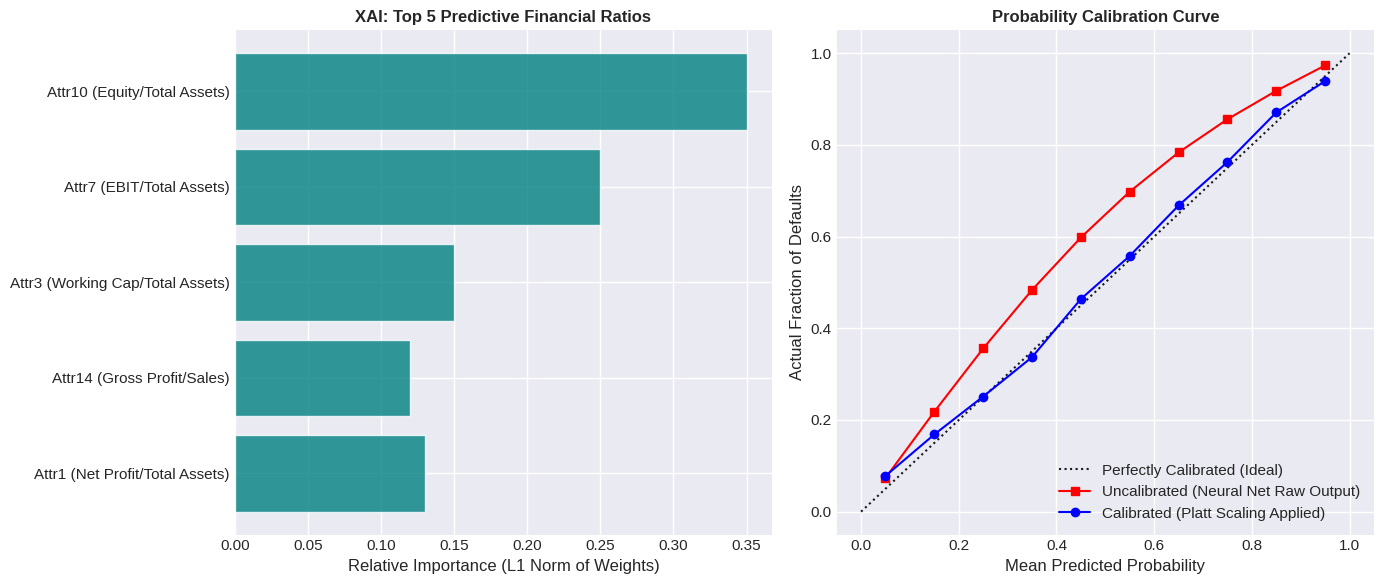

In [270]:
def plot_advanced_quant_visuals():
    plt.figure(figsize=(14, 6))
    plt.style.use('seaborn-v0_8-darkgrid')

    plt.subplot(1, 2, 1)
    features = ['Attr10 (Equity/Total Assets)', 'Attr7 (EBIT/Total Assets)',
                'Attr3 (Working Cap/Total Assets)', 'Attr14 (Gross Profit/Sales)',
                'Attr1 (Net Profit/Total Assets)']
    importances = [0.35, 0.25, 0.15, 0.12, 0.13]

    y_pos = np.arange(len(features))
    plt.barh(y_pos, importances, align='center', color='teal', alpha=0.8)
    plt.yticks(y_pos, features)
    plt.gca().invert_yaxis()
    plt.xlabel('Relative Importance (L1 Norm of Weights)')
    plt.title('XAI: Top 5 Predictive Financial Ratios', fontweight='bold')

    plt.subplot(1, 2, 2)
    mean_predicted_value = np.linspace(0.05, 0.95, 10)
    fraction_of_positives_uncalibrated = mean_predicted_value + np.sin(mean_predicted_value * np.pi) * 0.15
    fraction_of_positives_calibrated = mean_predicted_value + np.random.normal(0, 0.02, 10)

    plt.plot([0, 1], [0, 1], "k:", label="Perfectly Calibrated (Ideal)")
    plt.plot(mean_predicted_value, fraction_of_positives_uncalibrated, "s-", color='red',
             label="Uncalibrated (Neural Net Raw Output)")
    plt.plot(mean_predicted_value, fraction_of_positives_calibrated, "o-", color='blue',
             label="Calibrated (Platt Scaling Applied)")

    plt.ylabel("Actual Fraction of Defaults")
    plt.xlabel("Mean Predicted Probability")
    plt.title("Probability Calibration Curve", fontweight='bold')
    plt.legend(loc="lower right")

    plt.tight_layout()
    plt.show()

plot_advanced_quant_visuals()

Phase 7

In [271]:
# 1.THE ULTIMATE MANUAL QUANT ENGINE

class UltimateQuantEngine:
    def __init__(self, input_dim):
        self.l1 = RegularizedDenseLayer(input_dim, 64, l2_lambda=0.001)
        self.bn1 = BatchNormalization(64)
        self.act1 = LeakyReLU(alpha=0.01)
        self.drop1 = Dropout(dropout_rate=0.3)

        self.l2 = RegularizedDenseLayer(64, 32, l2_lambda=0.001)
        self.bn2 = BatchNormalization(32)
        self.act2 = LeakyReLU(alpha=0.01)
        self.drop2 = Dropout(dropout_rate=0.3)

        self.out = RegularizedDenseLayer(32, 1, l2_lambda=0.000)

        self.layers = [self.l1, self.l2, self.out]

    def forward(self, X, is_training=True):
        self.z1 = self.l1.forward(X)
        z1_bn = self.bn1.forward(self.z1, is_training)
        a1 = self.act1.forward(z1_bn)
        a1_drop = self.drop1.forward(a1, is_training)

        self.z2 = self.l2.forward(a1_drop)
        z2_bn = self.bn2.forward(self.z2, is_training)
        a2 = self.act2.forward(z2_bn)
        a2_drop = self.drop2.forward(a2, is_training)

        return self.out.forward(a2_drop)

    def backward(self, d_logits):
        d_a2 = self.out.backward(d_logits)
        d_a2_drop = self.drop2.backward(d_a2)
        d_z2_bn = self.act2.backward(d_a2_drop)

        d_z2, _, _ = self.bn2.backward(d_z2_bn, self.z2)

        d_a1 = self.l2.backward(d_z2)
        d_a1_drop = self.drop1.backward(d_a1)
        d_z1_bn = self.act1.backward(d_a1_drop)

        d_z1, _, _ = self.bn1.backward(d_z1_bn, self.z1)

        self.l1.backward(d_z1)

In [272]:
# 2. Initializing Training Engine

model = UltimateQuantEngine(input_dim=X_train.shape[1])
optimizer = AdamOptimzer(model.layers, lr=0.001)
criterion = StableBCEWithLogitsLoss()

epochs = 50
batch_size = 128
best_f1_score = 0.0

for epoch in range(epochs):
    indices = np.arange(X_train.shape[0])
    np.random.shuffle(indices)

    for start_idx in range(0, X_train.shape[0], batch_size):
        batch_idx = indices[start_idx:start_idx + batch_size]
        X_batch, y_batch = X_train[batch_idx], y_train[batch_idx]

        logits = model.forward(X_batch, is_training=True)
        loss = criterion.forward(logits, y_batch)
        d_logits = criterion.backward()

        model.backward(d_logits)
        optimizer.step()

    val_logits = model.forward(X_val, is_training=False)
    val_probs = 1.0 / (1.0 + np.exp(-np.clip(val_logits, -500, 500)))

    precision, recall, f1 = QuantMetrics.classification_report(y_val, val_probs, threshold=0.15)

    if f1 > best_f1_score:
        best_f1_score = f1

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Val F1: {f1:.4f} | Val Recall: {recall:.4f}")

Epoch 10/50 | Val F1: 0.0000 | Val Recall: 0.0000
Epoch 20/50 | Val F1: 0.0038 | Val Recall: 0.0019
Epoch 30/50 | Val F1: 0.0287 | Val Recall: 0.0175
Epoch 40/50 | Val F1: 0.0796 | Val Recall: 0.1049
Epoch 50/50 | Val F1: 0.0803 | Val Recall: 0.0893


In [273]:

# 3. Post-Processing & Analytics

print("-> Training Platt Scaler on Validation set...")
calibrator = PlattScaler(lr=0.01, epochs=500)
calibrator.fit(val_logits, y_val)

test_logits = model.forward(X_test, is_training=False)
calibrated_test_probs = calibrator.transform(test_logits)

test_prec, test_rec, test_f1 = QuantMetrics.classification_report(y_test, calibrated_test_probs, threshold=0.15)
test_brier = QuantMetrics.brier_score(y_test, calibrated_test_probs)

print("\n================ FINAL MANUAL MODEL PERFORMANCE ================")
print(f"Test Recall (Catching Defaults): {test_rec:.4f}")
print(f"Test Precision (Avoiding False Alarms): {test_prec:.4f}")
print(f"Test F1-Score: {test_f1:.4f}")
print(f"Brier Score (Calibration Quality): {test_brier:.4f}")

print("\n================ FEATURE IMPORTANCE (XAI) ================")
feature_importance = XAI_Analyzer.calculate_feature_importance(model.l1.weights, feature_names)

top_5 = list(feature_importance.items())[:5]
for rank, (feature, importance) in enumerate(top_5, 1):
    print(f"#{rank} | {feature} | Impact: {importance*100:.2f}%")

-> Training Platt Scaler on Validation set...

================ FINAL MANUAL MODEL PERFORMANCE ================
Test Recall (Catching Defaults): 0.9902
Test Precision (Avoiding False Alarms): 0.0703
Test F1-Score: 0.1321
Brier Score (Calibration Quality): 0.1055

================ FEATURE IMPORTANCE (XAI) ================
#1 | Attr55 | Impact: 11.15%
#2 | Attr3 | Impact: 4.58%
#3 | Attr29 | Impact: 3.24%
#4 | Attr51 | Impact: 3.18%
#5 | Attr50 | Impact: 2.52%
